In [1]:
# ── Standard libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn utilities ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# ── Display settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully ✓')

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully ✓


In [2]:
# ── Load raw training data ────────────────────────────────────────────────────
import os

data_path = os.path.join(
    os.path.expanduser('~'), 'Desktop',
    'Credit-Risk-Analytics-Portfolio',
    '01_scorecard_development', 'data',
    'application_train.csv'
)

df = pd.read_csv(data_path)

print(f'Raw data loaded ✓')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Target rate: {df["TARGET"].mean()*100:.2f}%')

Raw data loaded ✓
Shape: 307,511 rows × 122 columns
Target rate: 8.07%


In [14]:
# ── Calculate missing % per column ───────────────────────────────────────────
missing_pct = df.isnull().mean() *100

# Define threshold
MISSING_THRESHOLD = 40

# Identify columns to drop
cols_to_drop = missing_pct[missing_pct > MISSING_THRESHOLD].index.tolist()
print(f'Columns with >{MISSING_THRESHOLD}% missing: {len(cols_to_drop)}')
print(f'\nColumns being dropped:')
for col in cols_to_drop:
    print(f'  {col:<45} {missing_pct[col]:.1f}% missing')


Columns with >40% missing: 49

Columns being dropped:
  OWN_CAR_AGE                                   66.0% missing
  EXT_SOURCE_1                                  56.4% missing
  APARTMENTS_AVG                                50.7% missing
  BASEMENTAREA_AVG                              58.5% missing
  YEARS_BEGINEXPLUATATION_AVG                   48.8% missing
  YEARS_BUILD_AVG                               66.5% missing
  COMMONAREA_AVG                                69.9% missing
  ELEVATORS_AVG                                 53.3% missing
  ENTRANCES_AVG                                 50.3% missing
  FLOORSMAX_AVG                                 49.8% missing
  FLOORSMIN_AVG                                 67.8% missing
  LANDAREA_AVG                                  59.4% missing
  LIVINGAPARTMENTS_AVG                          68.4% missing
  LIVINGAREA_AVG                                50.2% missing
  NONLIVINGAPARTMENTS_AVG                       69.4% missing
  NONLIVINGAREA_

In [15]:
# ── Drop high missing columns ─────────────────────────────────────────────────
df = df.drop(columns=cols_to_drop)

print(f'Shape after dropping high-missing columns: {df.shape}')
print(f'Columns remaining: {df.shape[1]}')

Shape after dropping high-missing columns: (307511, 73)
Columns remaining: 73


In [18]:
# ── Anomaly 1: DAYS_EMPLOYED = 365243 ────────────────────────────────────────
# This value means the applicant is unemployed or retired
# It is NOT an actual employment duration of 1000 years
# Must be replaced with NaN before any calculations

anomaly_count = (df['DAYS_EMPLOYED'] == 365243).sum()
print(f'DAYS_EMPLOYED anomaly (365243) count: {anomaly_count:,}')
print(f'This is {anomaly_count/len(df)*100:.1f}% of all records')

# Replace with NaN
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
print(f'\nReplaced with NaN ✓')

DAYS_EMPLOYED anomaly (365243) count: 55,374
This is 18.0% of all records

Replaced with NaN ✓


In [19]:
df['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [22]:
# ── Anomaly 2: CODE_GENDER has 'XNA' values ───────────────────────────────────
# XNA means not available — treat as missing

if 'CODE_GENDER' in df.columns:
    xna_count = (df['CODE_GENDER'] == 'XNA').sum()
    print(f'CODE_GENDER XNA count: {xna_count}')
    df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', np.nan)
print('Replaced XNA with NaN ✓')

CODE_GENDER XNA count: 4
Replaced XNA with NaN ✓


In [23]:
# ── Convert DAYS columns to years (positive values) ───────────────────────────
# DAYS_BIRTH and DAYS_EMPLOYED are stored as negative integers
# Dividing by -365 converts to positive years

df['AGE_YEARS']           = -df['DAYS_BIRTH'] / 365
df['EMPLOYMENT_YEARS']    = -df['DAYS_EMPLOYED'] / 365
df['REGISTRATION_YEARS']  = -df['DAYS_REGISTRATION'] / 365
df['ID_PUBLISH_YEARS']    = -df['DAYS_ID_PUBLISH'] / 365

# ── Financial ratio features ──────────────────────────────────────────────────
# These ratios are standard in credit risk — used in affordability assessment

# Credit to Income ratio — how much credit relative to income
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

# Annuity to Income ratio — monthly repayment burden relative to income
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

# Credit to Goods Price ratio — loan to value equivalent
df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)

# Employment to Age ratio — proportion of life spent employed
df['EMPLOYMENT_AGE_RATIO'] = df['EMPLOYMENT_YEARS'] / (df['AGE_YEARS'] + 1)

print('Derived features created:')
derived_cols = [
    'AGE_YEARS', 'EMPLOYMENT_YEARS', 'REGISTRATION_YEARS',
    'ID_PUBLISH_YEARS', 'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'EMPLOYMENT_AGE_RATIO'
]
print(df[derived_cols].describe().T[['mean', 'min', 'max']].round(2).to_string())

Derived features created:
                        mean     min     max
AGE_YEARS            43.9400 20.5200 69.1200
EMPLOYMENT_YEARS      6.5300 -0.0000 49.0700
REGISTRATION_YEARS   13.6600 -0.0000 67.5900
ID_PUBLISH_YEARS      8.2000  0.0000 19.7200
CREDIT_INCOME_RATIO   3.9600  0.0000 84.7300
ANNUITY_INCOME_RATIO  0.1800  0.0000  1.8800
CREDIT_GOODS_RATIO    1.1200  0.1500  6.0000
EMPLOYMENT_AGE_RATIO  0.1500 -0.0000  0.7200


In [24]:
# ── Identify column types ─────────────────────────────────────────────────────
# Exclude ID and target columns from processing
exclude_cols = ['SK_ID_CURR', 'TARGET']

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_cols]

cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in exclude_cols]

print(f'Numerical columns : {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')
print(f'\nCategorical columns list:')
for col in cat_cols:
    print(f'  {col:<40} unique values: {df[col].nunique()}')

Numerical columns : 67
Categorical columns: 12

Categorical columns list:
  NAME_CONTRACT_TYPE                       unique values: 2
  CODE_GENDER                              unique values: 2
  FLAG_OWN_CAR                             unique values: 2
  FLAG_OWN_REALTY                          unique values: 2
  NAME_TYPE_SUITE                          unique values: 7
  NAME_INCOME_TYPE                         unique values: 8
  NAME_EDUCATION_TYPE                      unique values: 5
  NAME_FAMILY_STATUS                       unique values: 6
  NAME_HOUSING_TYPE                        unique values: 6
  OCCUPATION_TYPE                          unique values: 18
  WEEKDAY_APPR_PROCESS_START               unique values: 7
  ORGANIZATION_TYPE                        unique values: 58


In [25]:
imputation_stats = []

# ── Numerical imputation — Median ─────────────────────────────────────────────
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col]    = df[col].fillna(median_val)
        imputation_stats.append({
            'Column'          : col,
            'Type'            : 'Numerical',
            'Method'          : 'Median',
            'Imputation Value': round(median_val, 4),
            'Missing Before'  : df[col].isnull().sum()
        })

# ── Categorical imputation — Mode ─────────────────────────────────────────────
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col]  = df[col].fillna(mode_val)
        imputation_stats.append({
            'Column'          : col,
            'Type'            : 'Categorical',
            'Method'          : 'Mode',
            'Imputation Value': mode_val,
            'Missing Before'  : 0
        })

# Save imputation stats to CSV for documentation
imputation_df = pd.DataFrame(imputation_stats)
imputation_df.to_csv('../outputs/imputation_stats.csv', index=False)

print(f'Imputation complete ✓')
print(f'Columns imputed: {len(imputation_stats)}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Imputation complete ✓
Columns imputed: 24
Remaining missing values: 0


In [26]:
winsorize_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO',
    'AGE_YEARS', 'EMPLOYMENT_YEARS', 'EMPLOYMENT_AGE_RATIO'
]

# Filter to only columns that exist after our drops
winsorize_cols = [c for c in winsorize_cols if c in df.columns]

cap_stats = []

for col in winsorize_cols:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)

    # Count how many values will be capped
    n_lower = (df[col] < p01).sum()
    n_upper = (df[col] > p99).sum()

    # Apply cap
    df[col] = df[col].clip(lower=p01, upper=p99)

    cap_stats.append({
        'Column'       : col,
        'Lower Cap (1%)': round(p01, 2),
        'Upper Cap (99%)': round(p99, 2),
        'Capped Lower' : n_lower,
        'Capped Upper' : n_upper
    })

cap_df = pd.DataFrame(cap_stats)
print('Winsorization complete ✓')
print(cap_df.to_string(index=False))

Winsorization complete ✓
              Column  Lower Cap (1%)  Upper Cap (99%)  Capped Lower  Capped Upper
    AMT_INCOME_TOTAL      45000.0000      472500.0000          1508          3014
          AMT_CREDIT      76410.0000     1854000.0000          2736          3075
         AMT_ANNUITY       6183.0000       70006.5000          3075          3070
     AMT_GOODS_PRICE      67500.0000     1800000.0000          2062          1431
 CREDIT_INCOME_RATIO          0.6000          13.0300          3076          3076
ANNUITY_INCOME_RATIO          0.0400           0.4800          3075          3076
  CREDIT_GOODS_RATIO          1.0000           1.4800          2915          3020
           AGE_YEARS         22.6400          66.9000          3075          3074
    EMPLOYMENT_YEARS          0.3200          29.8500          3023          3076
EMPLOYMENT_AGE_RATIO          0.0100           0.5700          3076          3076


In [27]:
# ── Label encode binary categorical variables ─────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = []
multi_cols  = []

for col in cat_cols:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col].astype(str))
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print(f'Binary encoded (Label Encoding): {len(binary_cols)} columns')
print(f'Multi-category (One-Hot pending): {len(multi_cols)} columns')
print(f'\nBinary encoded columns:')
for col in binary_cols:
    print(f'  {col}')

Binary encoded (Label Encoding): 4 columns
Multi-category (One-Hot pending): 8 columns

Binary encoded columns:
  NAME_CONTRACT_TYPE
  CODE_GENDER
  FLAG_OWN_CAR
  FLAG_OWN_REALTY


In [28]:
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f'One-hot encoding complete ✓')
print(f'Shape after encoding: {df.shape}')

One-hot encoding complete ✓
Shape after encoding: (307511, 180)


In [29]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,...,ORGANIZATION_TYPE_Culture,ORGANIZATION_TYPE_Electricity,ORGANIZATION_TYPE_Emergency,ORGANIZATION_TYPE_Government,ORGANIZATION_TYPE_Hotel,ORGANIZATION_TYPE_Housing,ORGANIZATION_TYPE_Industry: type 1,ORGANIZATION_TYPE_Industry: type 10,ORGANIZATION_TYPE_Industry: type 11,ORGANIZATION_TYPE_Industry: type 12,ORGANIZATION_TYPE_Industry: type 13,ORGANIZATION_TYPE_Industry: type 2,ORGANIZATION_TYPE_Industry: type 3,ORGANIZATION_TYPE_Industry: type 4,ORGANIZATION_TYPE_Industry: type 5,ORGANIZATION_TYPE_Industry: type 6,ORGANIZATION_TYPE_Industry: type 7,ORGANIZATION_TYPE_Industry: type 8,ORGANIZATION_TYPE_Industry: type 9,ORGANIZATION_TYPE_Insurance,ORGANIZATION_TYPE_Kindergarten,ORGANIZATION_TYPE_Legal Services,ORGANIZATION_TYPE_Medicine,ORGANIZATION_TYPE_Military,ORGANIZATION_TYPE_Mobile,ORGANIZATION_TYPE_Other,ORGANIZATION_TYPE_Police,ORGANIZATION_TYPE_Postal,ORGANIZATION_TYPE_Realtor,ORGANIZATION_TYPE_Religion,ORGANIZATION_TYPE_Restaurant,ORGANIZATION_TYPE_School,ORGANIZATION_TYPE_Security,ORGANIZATION_TYPE_Security Ministries,ORGANIZATION_TYPE_Self-employed,ORGANIZATION_TYPE_Services,ORGANIZATION_TYPE_Telecom,ORGANIZATION_TYPE_Trade: type 1,ORGANIZATION_TYPE_Trade: type 2,ORGANIZATION_TYPE_Trade: type 3,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA
0,100002,1,0,1,0,1,0,202500.0000,406597.5000,24700.5000,351000.0000,0.0188,-9461,-637.0000,-3648.0000,-2120,1,1,0,1,1,0,1.0000,2,2,10,0,0,0,0,0,0,0.2629,0.1394,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,100003,0,0,0,0,0,0,270000.0000,1293502.5000,35698.5000,1129500.0000,0.0035,-16765,-1188.0000,-1186.0000,-291,1,1,0,1,1,0,2.0000,1,1,11,0,0,0,0,0,0,0.6222,0.5353,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,100004,0,1,1,1,1,0,67500.0000,135000.0000,6750.0000,135000.0000,0.0100,-19046,-225.0000,-4260.0000,-2531,1,1,1,1,1,0,1.0000,2,2,9,0,0,0,0,0,0,0.5559,0.7296,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [31]:
df.shape

(307511, 180)

In [32]:
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

print(f'Features (X) shape: {X.shape}')
print(f'Target  (y) shape: {y.shape}')
print(f'Target rate: {y.mean()*100:.2f}%')

Features (X) shape: (307511, 178)
Target  (y) shape: (307511,)
Target rate: 8.07%


In [33]:
# ── Train / OOT split ─────────────────────────────────────────────────────────
# stratify=y ensures BOTH splits have the same default rate
# This is critical — without stratify, one split could have very different default rates
# random_state=42 ensures reproducibility — same split every time you run the code

X_train, X_oot, y_train, y_oot = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train / OOT Split Summary')
print('='*45)
print(f'Training set   : {X_train.shape[0]:>7,} rows | Default rate: {y_train.mean()*100:.2f}%')
print(f'OOT set        : {X_oot.shape[0]:>7,} rows | Default rate: {y_oot.mean()*100:.2f}%')
print(f'Total          : {len(X):>7,} rows')
print(f'\nSplit ratio: {X_train.shape[0]/len(X)*100:.0f}% train / {X_oot.shape[0]/len(X)*100:.0f}% OOT')

Train / OOT Split Summary
Training set   : 246,008 rows | Default rate: 8.07%
OOT set        :  61,503 rows | Default rate: 8.07%
Total          : 307,511 rows

Split ratio: 80% train / 20% OOT


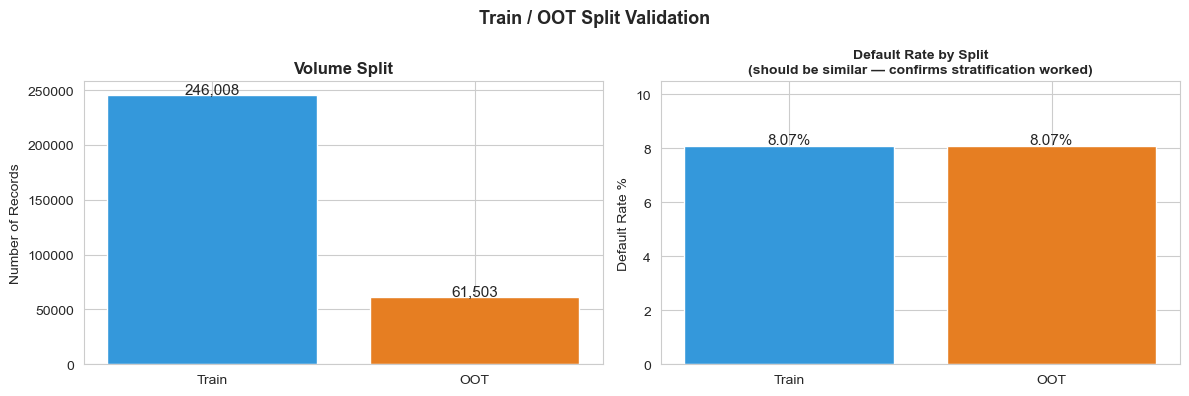

Chart saved ✓


In [34]:
 #── Visualise split ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Volume split
axes[0].bar(['Train', 'OOT'], [len(X_train), len(X_oot)],
            color=['#3498db', '#e67e22'], edgecolor='white')
axes[0].set_title('Volume Split', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate([len(X_train), len(X_oot)]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

# Default rate comparison
rates = [y_train.mean()*100, y_oot.mean()*100]
bars  = axes[1].bar(['Train', 'OOT'], rates,
                    color=['#3498db', '#e67e22'], edgecolor='white')
axes[1].set_title('Default Rate by Split\n(should be similar — confirms stratification worked)',
                  fontsize=10, fontweight='bold')
axes[1].set_ylabel('Default Rate %')
axes[1].set_ylim(0, max(rates) * 1.3)
for bar, rate in zip(bars, rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{rate:.2f}%', ha='center', fontsize=11)

plt.suptitle('Train / OOT Split Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/10_train_oot_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [35]:
# ── Reconstruct full train and OOT DataFrames with TARGET ─────────────────────
train_df = X_train.copy()
train_df['TARGET'] = y_train.values

oot_df = X_oot.copy()
oot_df['TARGET'] = y_oot.values

# ── Save to data folder ───────────────────────────────────────────────────────
train_path = os.path.join(
    os.path.expanduser('~'), 'Desktop',
    'Credit-Risk-Analytics-Portfolio',
    '01_scorecard_development', 'data', 'train_clean.csv'
)
oot_path = os.path.join(
    os.path.expanduser('~'), 'Desktop',
    'Credit-Risk-Analytics-Portfolio',
    '01_scorecard_development', 'data', 'oot_clean.csv'
)

train_df.to_csv(train_path, index=False)
oot_df.to_csv(oot_path,   index=False)

print('Datasets saved ✓')
print(f'Train: {train_path}')
print(f'OOT  : {oot_path}')

Datasets saved ✓
Train: /Users/shivamverma/Desktop/Credit-Risk-Analytics-Portfolio/01_scorecard_development/data/train_clean.csv
OOT  : /Users/shivamverma/Desktop/Credit-Risk-Analytics-Portfolio/01_scorecard_development/data/oot_clean.csv


In [36]:
# ── Final preprocessing summary ───────────────────────────────────────────────
print('='*65)
print('  PREPROCESSING SUMMARY')
print('='*65)
print(f"""
INPUT
  Raw shape              : 307,511 rows × 122 columns

STEPS COMPLETED
  1. Dropped high-missing columns (>{MISSING_THRESHOLD}%): {len(cols_to_drop)} columns removed
  2. Fixed DAYS_EMPLOYED anomaly (365243 → NaN)
  3. Fixed CODE_GENDER XNA → NaN
  4. Created 8 derived features (age, ratios)
  5. Imputed missing — median for numerical, mode for categorical
  6. Winsorized outliers at 1st/99th percentile: {len(winsorize_cols)} columns
  7. Label encoded binary variables: {len(binary_cols)} columns
  8. One-hot encoded multi-category variables: {len(multi_cols)} columns
  9. Train/OOT split — 80/20 stratified

OUTPUT
  Final feature count    : {X.shape[1]} columns
  Training set           : {len(X_train):,} rows | Default rate: {y_train.mean()*100:.2f}%
  OOT set                : {len(X_oot):,} rows | Default rate: {y_oot.mean()*100:.2f}%
  Remaining missing      : {df.isnull().sum().sum()}

FILES SAVED
  train_clean.csv        → ready for WOE/IV binning
  oot_clean.csv          → reserved for model validation
  imputation_stats.csv   → model documentation
  10_train_oot_split.png → outputs folder
""")
print('='*65)
print('  PREPROCESSING COMPLETE — Next: 03_woe_iv_binning.ipynb')
print('='*65)

  PREPROCESSING SUMMARY

INPUT
  Raw shape              : 307,511 rows × 122 columns

STEPS COMPLETED
  1. Dropped high-missing columns (>40%): 49 columns removed
  2. Fixed DAYS_EMPLOYED anomaly (365243 → NaN)
  3. Fixed CODE_GENDER XNA → NaN
  4. Created 8 derived features (age, ratios)
  5. Imputed missing — median for numerical, mode for categorical
  6. Winsorized outliers at 1st/99th percentile: 10 columns
  7. Label encoded binary variables: 4 columns
  8. One-hot encoded multi-category variables: 8 columns
  9. Train/OOT split — 80/20 stratified

OUTPUT
  Final feature count    : 178 columns
  Training set           : 246,008 rows | Default rate: 8.07%
  OOT set                : 61,503 rows | Default rate: 8.07%
  Remaining missing      : 0

FILES SAVED
  train_clean.csv        → ready for WOE/IV binning
  oot_clean.csv          → reserved for model validation
  imputation_stats.csv   → model documentation
  10_train_oot_split.png → outputs folder

  PREPROCESSING COMPLETE — Ne